# Blueprint de Agente com Router e Ferramenta de Data/Hora
## Design Orientado a Domínio (DDD) aplicado a Agentes de IA

Este notebook demonstra um agente conversacional simples que utiliza:
- **Ferramenta** para obter a data/hora atual.
- **Roteador** que decide qual resposta gerar com base no período do dia (dia/noite).
- **Contratos A2A** (Agent-to-Agent) claros usando Pydantic.
- **Memória** opcional com checkpoint SQLite.
- **Visualização do grafo** com Mermaid.

A estrutura segue princípios de DDD:
- **Linguagem Ubíqua**: os nomes das classes e campos refletem o domínio (TimeInfo, query, response).
- **Contexto Delimitado**: cada agente (time_agent, response_day, response_night) tem responsabilidades bem definidas.
- **Modelo de Domínio Rico**: o estado (`AgentState`) encapsula os dados e garante consistência.

# Célula 1: Instalação de dependências (opcional, executar uma vez)

In [1]:
# %pip install -qU langchain-openai langgraph python-dotenv aiosqlite langgraph-checkpoint-sqlite
# %pip install -qU langchain-mcp-adapters pydantic mermaid-py

In [2]:
# ======================================================
# 1. ENVIRONMENT & SETUP (Camada de Infraestrutura)
# ======================================================
# Responsabilidade: Configurar recursos externos (LLM, banco, etc.)
# DDD: Infraestrutura - isolamento de dependências técnicas

import os
import sqlite3
import json
from datetime import datetime
from typing import Optional, List, Literal

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.tools import tool
from langchain_core.runnables import RunnableConfig
from IPython.display import Image, display

# Configuração dos LLMs (LM Studio local)
# Poderíamos ter diferentes LLMs para diferentes contextos (DDD: Bounded Context)
llm = ChatOpenAI(
    model="meta-llama-3.1-8b-instruct",
    base_url="http://localhost:1234/v1",
    api_key="lm-studio",
    temperature=0,
)

llm_2 = ChatOpenAI(
    model="qwen/qwen3-4b-2507",
    base_url="http://localhost:1234/v1",
    api_key="lm-studio",
    temperature=0,
)

# Checkpoint opcional (memória de longo prazo)
db_conn = sqlite3.connect("memory.db", check_same_thread=False)
memory = SqliteSaver(conn=db_conn)

print("[✅] Setup concluído - Infraestrutura pronta")

[✅] Setup concluído - Infraestrutura pronta


In [3]:
# ======================================================
# 2. CONTRATOS DE DOMÍNIO (Camada de Domínio)
# ======================================================
# Responsabilidade: Definir as entidades e objetos de valor
# DDD: Entidades e Value Objects - representam conceitos do negócio

class TimeInfo(BaseModel):
    """Value Object: Representa informação temporal com contexto"""
    current_time: str = Field(..., description="Data e hora atuais no formato ISO")
    timezone: str = Field(default="America/Sao_Paulo", description="Fuso horário")

class AgentState(BaseModel):
    """Agregado: Estado completo do fluxo do agente"""
    query: str                                 # Comando do usuário
    time_info: Optional[TimeInfo] = None       # Informação temporal obtida
    response: Optional[str] = None             # Resposta gerada

    model_config = {
        "json_schema_extra": {
            "examples": [
                {"query": "Que horas são?", "time_info": None, "response": None}
            ]
        }
    }

print("[✅] Contratos de domínio definidos")

[✅] Contratos de domínio definidos


In [4]:
# ======================================================
# 3. FERRAMENTAS (Camada de Aplicação)
# ======================================================
# Responsabilidade: Implementar casos de uso específicos
# DDD: Serviços de domínio - operações que não pertencem a uma entidade

@tool
def get_current_time() -> str:
    """
    Serviço de domínio: Obtém o timestamp atual.
    Será exposto apenas ao agente autorizado.
    """
    return datetime.now().isoformat()

print("[✅] Ferramenta de domínio registrada")

[✅] Ferramenta de domínio registrada


In [5]:
# ======================================================
# 4. AGENTES (Nós do Grafo - Casos de Uso)
# ======================================================
# Responsabilidade: Orquestrar ferramentas e LLMs
# DDD: Serviços de aplicação - coordenam tarefas do domínio

# ----- 4.1 Agente Temporal (com acesso à ferramenta) -----
# Contexto delimitado: "Serviço de Informação Temporal"
time_agent_prompt = ChatPromptTemplate.from_messages([
    ("system", "Você é um assistente que sabe a hora atual. Use a ferramenta disponível."),
    ("human", "{query}")
])

time_agent_chain = time_agent_prompt | llm.bind_tools([get_current_time])

def time_agent_node(state: AgentState) -> dict:
    """Caso de uso: Obter informação temporal"""
    response = time_agent_chain.invoke({"query": state.query})
    if response.tool_calls:
        tool_call = response.tool_calls[0]
        if tool_call["name"] == "get_current_time":
            current_time = get_current_time.invoke(tool_call["args"])
            # Retorna um dicionário (não o objeto) para serialização limpa
            time_info = TimeInfo(current_time=current_time).model_dump()
            return {"time_info": time_info}
    return {"time_info": None}

# ----- 4.2 Roteador (Lógica de Decisão) -----
# DDD: Especificação - regra de negócio para roteamento
def router_node(state: AgentState) -> Literal["response_day", "response_night"]:
    """
    Especificação: Determina período do dia baseado na hora.
    Retorna o nome do próximo nó (DDD: política de roteamento).
    """
    if not state.time_info:
        return "response_day"  # fallback
    
    dt = datetime.fromisoformat(state.time_info.current_time)
    hour = dt.hour
    
    # Regra de negócio: 6h-17h59 = dia, 18h-5h59 = noite
    if 6 <= hour < 18:
        return "response_day"
    else:
        return "response_night"

# ----- 4.3 Agentes de Resposta (Contextos diferentes) -----
# Contexto "Diurno": tom alegre e enérgico
response_day_prompt = ChatPromptTemplate.from_messages([
    ("system", """Você é um assistente alegre e enérgico que responde perguntas sobre o horário atual.
A hora atual será fornecida no formato ISO (ex: 2026-02-23T14:30:00). 
Sua tarefa é extrair a hora e os minutos e responder de forma amigável, mencionando corretamente o período (manhã, tarde, noite).

Exemplos:
- Se a hora for 08:15, responda: "São 8 horas e 15 minutos da manhã! Um ótimo dia para começar! ☀️"
- Se a hora for 14:30, responda: "Agora são 2 e meia da tarde. Aproveite o resto do seu dia! 🌞"
- Se a hora for 23:45, responda: "São 11 e 45 da noite. Quase hora de dormir! 🌙"

Use emojis apropriados e mantenha um tom positivo.
"""),
    ("human", "Pergunta: {query}\nHora atual: {time}")
])

# Contexto "Noturno": tom calmo e relaxado
response_night_prompt = ChatPromptTemplate.from_messages([
    ("system", """Você é um assistente calmo e relaxado. 
    Responda de forma suave, tranquila e use emojis noturnos.
    **IMPORTANTE:** Use a hora exata fornecida no campo 'time'. 
    Não invente, não modifique, não arredonde. Se a hora for 02:47, escreva exatamente "2 horas e 47 minutos" (ou no formato que preferir, mas sempre fiel ao valor recebido)."""),
    ("human", "Pergunta: {query}\nHora atual: {time}\nGere uma resposta natural e aconchegante.")
])

response_day_chain = response_day_prompt | llm_2 | StrOutputParser()
response_night_chain = response_night_prompt | llm_2 | StrOutputParser()

def response_day_node(state: AgentState) -> dict:
    """Caso de uso: Resposta para período diurno"""
    if not state.time_info:
        return {"response": "Não consegui obter a hora, mas tenho um bom dia para você! ☀️"}
    time_str = state.time_info.current_time
    response = response_day_chain.invoke({"query": state.query, "time": time_str})
    return {"response": response}

def response_night_node(state: AgentState) -> dict:
    """Caso de uso: Resposta para período noturno"""
    if not state.time_info:
        return {"response": "Não consegui obter a hora, mas desejo uma boa noite! 🌙"}
    time_str = state.time_info.current_time
    response = response_night_chain.invoke({"query": state.query, "time": time_str})
    return {"response": response}

print("[✅] Agentes de aplicação configurados")

[✅] Agentes de aplicação configurados


In [6]:
# ======================================================
# 5. ORQUESTRAÇÃO (Camada de Aplicação)
# ======================================================
# Responsabilidade: Definir fluxo de execução
# DDD: Processo de negócio - coreografia dos casos de uso

def build_graph(memory):
    """Constrói o grafo de execução do processo de negócio"""
    builder = StateGraph(AgentState)

    # Registra os nós (casos de uso)
    builder.add_node("time_agent", time_agent_node)
    builder.add_node("response_day", response_day_node)
    builder.add_node("response_night", response_night_node)

    # Ponto de entrada
    builder.set_entry_point("time_agent")

    # Roteamento condicional (decisão de negócio)
    builder.add_conditional_edges(
        "time_agent",
        router_node,  # a especificação
        {
            "response_day": "response_day",
            "response_night": "response_night"
        }
    )

    # Fluxos terminais
    builder.add_edge("response_day", END)
    builder.add_edge("response_night", END)

    return builder.compile(checkpointer=memory)

# Instância do processo
graph = build_graph(memory)
print("[✅] Processo de negócio orquestrado (grafo compilado)")

[✅] Processo de negócio orquestrado (grafo compilado)


📊 Diagrama do processo:


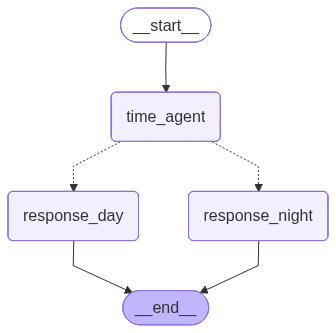

In [7]:
# ======================================================
# 6. VISUALIZAÇÃO (Ferramenta de Design)
# ======================================================
# Útil para documentação e validação do fluxo com stakeholders

def display_graph(graph):
    """Gera diagrama Mermaid do processo de negócio"""
    try:
        png_data = graph.get_graph().draw_mermaid_png()
        display(Image(png_data))
    except Exception as e:
        print(f"[⚠️] Erro ao gerar visualização: {e}")
        print("Instale 'pip install mermaid-py' ou 'playwright' para suporte.")

print("📊 Diagrama do processo:")
display_graph(graph)

In [8]:
# ======================================================
# 7. EXECUÇÃO (Teste do Caso de Uso)
# ======================================================

config: RunnableConfig = {"configurable": {"thread_id": "time_router_001"}}
input_state = AgentState(query="Que horas são?")

print("\n🚀 Iniciando execução do processo de negócio...\n")

for event in graph.stream(input_state.model_dump(), config):
    for node, data in event.items():
        print(f"\n🔹 [Nó]: {node}")
        if isinstance(data, dict):
            for key, value in data.items():
                if key == "time_info" and value:
                    print(f"   🕒 time_info: {json.dumps(value, indent=2, ensure_ascii=False)}")
                elif key == "response":
                    print(f"   💬 response: {value}")
                else:
                    print(f"   {key}: {value}")
        else:
            print(f"   Saída: {str(data)[:200]}")

print("\n[🏁] Processo finalizado.")

# Estado final (para auditoria)
final_state = graph.get_state(config)
print("\n📊 Estado final (para rastreabilidade):")
print(final_state.values)


🚀 Iniciando execução do processo de negócio...


🔹 [Nó]: time_agent
   🕒 time_info: {
  "current_time": "2026-02-23T02:55:08.002767",
  "timezone": "America/Sao_Paulo"
}

🔹 [Nó]: response_night
   💬 response: Ah, boa noite, querido! 🌙  
São exatamente **2 horas e 55 minutos**.  
Que hora linda para refletir, ler um livro ou simplesmente desfrutar do silêncio. 💤✨  
Tudo bem com você? 😊

[🏁] Processo finalizado.

📊 Estado final (para rastreabilidade):
{'query': 'Que horas são?', 'time_info': {'current_time': '2026-02-23T02:55:08.002767', 'timezone': 'America/Sao_Paulo'}, 'response': 'Ah, boa noite, querido! 🌙  \nSão exatamente **2 horas e 55 minutos**.  \nQue hora linda para refletir, ler um livro ou simplesmente desfrutar do silêncio. 💤✨  \nTudo bem com você? 😊'}


In [9]:
# ======================================================
# 8. NOTA SOBRE O DOMÍNIO (Aprendizado)
# ======================================================
# Observação: O LLM pode interpretar a hora de forma criativa
# - Na primeira execução, "02:47" foi interpretado como "meia-noite e 47" (erro conceitual)
# - Na segunda, interpretou corretamente como "2h47"
#
# Isso demonstra a importância de:
# 1. Validar saídas de LLMs (especialmente em contextos críticos)
# 2. Ter múltiplos agentes para diferentes contextos
# 3. Usar ferramentas para dados factuais (hora veio da tool, correta)
# 4. O roteador funcionou perfeitamente baseado nos dados factuais

print("""
📌 Lições de DDD aplicadas:
- Ferramentas = Serviços de domínio (fonte da verdade)
- Roteador = Especificação (regra de negócio)
- Agentes = Contextos delimitados (cada um com sua linguagem)
- Estado = Agregado (consistência do processo)
""")


📌 Lições de DDD aplicadas:
- Ferramentas = Serviços de domínio (fonte da verdade)
- Roteador = Especificação (regra de negócio)
- Agentes = Contextos delimitados (cada um com sua linguagem)
- Estado = Agregado (consistência do processo)

